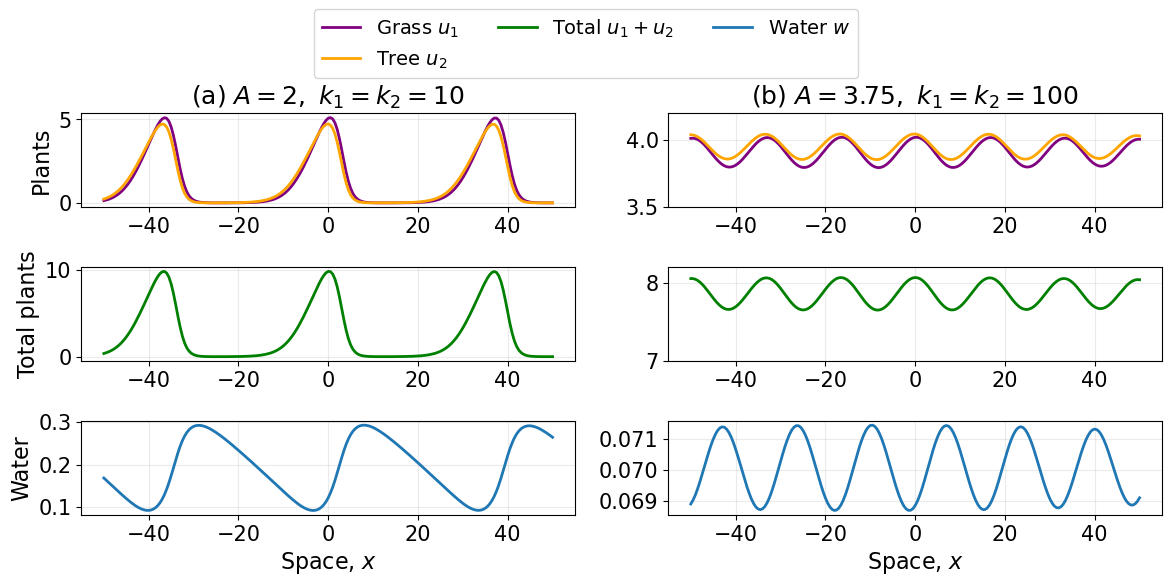

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#chi parameterisation (this chi parameterisation wasnt talked about in my dissertation)
#(this is quantifying the difference between the two species)
def species_params_from_chi(chi, B1, B2_tilde, F_tilde, H_tilde, D_tilde):
    B2 = B1 - chi*(B1 - B2_tilde)
    F  = 1.0 - chi*(1.0 - F_tilde)
    H  = 1.0 - chi*(1.0 - H_tilde)
    D  = 1.0 - chi*(1.0 - D_tilde)
    return B2, F, H, D


#IMEX+FFT solver 
def simulate_two_species(
    A, k1, k2, *, chi=0.3, B1=0.45,
    B2_tilde=0.004, F_tilde=0.01, H_tilde=0.01, D_tilde=0.01,
    nu=182.5, d=500.0, dx=0.5, L=800.0, dt=0.005, T=1500.0,
    seed=0,
):
    B2, F, H, D = species_params_from_chi(chi, B1, B2_tilde, F_tilde, H_tilde, D_tilde)

    N = int(L/dx)
    x = np.linspace(-L/2, L/2, N, endpoint=False)

    kk = 2*np.pi*np.fft.fftfreq(N, d=dx)

    den_u1 = 1.0 + dt*(B1 + (kk**2))
    den_u2 = 1.0 + dt*(B2 + D*(kk**2))
    den_w  = 1.0 + dt*(1.0 + d*(kk**2)) - 1j*dt*nu*kk

    #Start near a the steady uniform state 
    rng = np.random.default_rng(seed)
    u1 = 0.2 + 0.02*(rng.random(N) - 0.5)
    u2 = 0.2 + 0.02*(rng.random(N) - 0.5)
    w  = A*np.ones(N) + 0.02*(rng.random(N) - 0.5)

    u1 = np.maximum(u1, 0.0)
    u2 = np.maximum(u2, 0.0)
    w  = np.maximum(w,  1e-8)

    u1_0, u2_0, w_0 = u1.copy(), u2.copy(), w.copy()

    nsteps = int(round(T/dt))
    for _ in range(nsteps):
        common = (u1 + H*u2)

        g1 = w*u1*common*(1.0 - u1/k1)
        g2 = F*w*u2*common*(1.0 - u2/k2)

        uptake = w*(u1 + u2)*common

        Ru1 = g1
        Ru2 = g2
        Rw  = A - uptake

        u1_hat = np.fft.fft(u1)
        u2_hat = np.fft.fft(u2)
        w_hat  = np.fft.fft(w)

        u1 = np.fft.ifft((u1_hat + dt*np.fft.fft(Ru1)) / den_u1).real
        u2 = np.fft.ifft((u2_hat + dt*np.fft.fft(Ru2)) / den_u2).real
        w  = np.fft.ifft((w_hat  + dt*np.fft.fft(Rw )) / den_w ).real

        u1 = np.maximum(u1, 0.0)
        u2 = np.maximum(u2, 0.0)
        w  = np.maximum(w,  1e-8)   

    total = u1 + u2
    shift = (N//2) - int(np.argmax(total))
    u1 = np.roll(u1, shift)
    u2 = np.roll(u2, shift)
    w  = np.roll(w,  shift)

    return x, u1_0, u2_0, w_0, u1, u2, w

def plot_simulation():
    cases = [
        dict(A=2.0,   k1=10.0,  k2=10.0,  title=r"(a) $A=2,\ k_1=k_2=10$"),
        dict(A=3.75,  k1=100.0, k2=100.0, title=r"(b) $A=3.75,\ k_1=k_2=100$"),
    ]
    plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14
        })
    fig, ax = plt.subplots(3, 2, figsize=(12, 6), sharex=False)

    for j, case in enumerate(cases):
        title = case.pop("title")
        x, u1_0, u2_0, w_0, u1, u2, w = simulate_two_species(**case)

        mask = (x >= -50) & (x <= 50)

        #Top: u1 (grass) and u2 (tree)
        ax[0, j].plot(x[mask], u1[mask], lw=2, color="purple", label=r"Grass $u_1$")
        ax[0, j].plot(x[mask], u2[mask], lw=2, label=r"Tree $u_2$", color = "orange")
        ax[0, j].set_title(title)
        ax[0, j].set_ylabel("Plants" if j == 0 else "")
        ax[0, j].grid(alpha=0.25)

        #Middle: total plants
        ax[1, j].plot(x[mask], (u1 + u2)[mask], lw=2, color="green", label=r"Total $u_1+u_2$")
        ax[1, j].set_ylabel("Total plants" if j == 0 else "")
        ax[1, j].grid(alpha=0.25)

        #Bottom: water
        ax[2, j].plot(x[mask], w[mask], lw=2, label=r"Water $w$")
        ax[2, j].set_xlabel(r"Space, $x$")
        ax[2, j].set_ylabel("Water" if j == 0 else "")
        ax[2, j].grid(alpha=0.25)

    ax[0, 1].set_ylim(3.5, 4.2)
    ax[1, 1].set_ylim(7, 8.2)
    #legend
    handles, labels = ax[0,0].get_legend_handles_labels()
    h2, l2 = ax[1,0].get_legend_handles_labels()
    h3, l3 = ax[2,0].get_legend_handles_labels()
    fig.legend(handles + h2 + h3, labels + l2 + l3, loc="upper center", ncol=3, frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.savefig("Numeric Simulation 2 Species.pdf", format="pdf")
    plt.show()

plot_simulation()